
# MainGames Data Scientist Analysis

**Objective:** Identify factors that influence `PaidStarPerWatchedHour` and generate business recommendations.


In [273]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")

df = pd.read_csv("D:/Dinda/Maingames/data/Maingames_DS_dataset.csv")
print(df.shape)
df.head()


(631, 127)


,Unnamed: 0,Country,Gender,Game,Total Follower,Broadcast Hours,PaidStarPerWatchedHour,Character_Facet_Cont_Rigidity,Character_Facet_Cont_AchievementStriving,Personal_Values_Facet_Cont_Hedonism,...,Personal_Values_Facet_Cont_UniversalismNature,Role_Charismatic,Personal_Values_Facet_Cont_Tradition,Self_Esteem_Cont_SELevelAppearance,Character_Facet_Cont_Assertiveness,Character_Facet_Cont_Cautiousness,Role_Curator,Personal_Values_Cont_Conservation,Self_Esteem_Cont_SELevelIntelligence,Temperament_Centric
0,0,ID,Male,MLBB,96751,104,0.004113,0.663442,0.718679,0.288008,...,0.523116,0.408444,0.318747,0.684412,0.494384,0.751974,0.524306,0.299052,0.803920,0.625
1,1,ID,Male,8 Ball Pool,4781,174,0.002855,0.543255,0.427887,0.430609,...,0.444493,0.407624,0.382594,0.635493,0.468738,0.571198,0.100202,0.304527,0.751291,0.125
2,2,ID,Female,Free Fire - Battlegrounds,68246,83,0.003007,0.527279,0.399873,0.753009,...,0.581657,0.443453,0.325263,0.398686,0.515929,0.309322,0.070988,0.305975,0.759900,0.000
3,3,ID,Male,MLBB,142037,127,0.005171,0.677222,0.603534,0.407923,...,0.385822,0.408994,0.440821,0.703669,0.516412,0.535322,0.214652,0.298592,0.734010,0.000
4,4,ID,Male,Free Fire - Battlegrounds,15416,86,0.001213,0.238194,0.543285,0.392993,...,0.582025,0.135650,0.405968,0.439668,0.586193,0.567604,0.324364,0.298716,0.814530,0.125


## 1. Data Overview

In [274]:

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 631 entries, 0 to 630
Columns: 127 entries, Unnamed: 0 to Temperament_Centric
dtypes: float64(120), int64(2), str(5)
memory usage: 626.2 KB


In [275]:

df.describe(include="all").T.head(20)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,631.0,NaN,NaN,NaN,465.057052,313.809365,0.0,160.5,432.0,787.5,946.0
Country,631,3,VN,240,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,630,3,Male,453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Game,629,65,MLBB,151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total Follower,630,628,40837,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Broadcast Hours,631.0,NaN,NaN,NaN,127.870048,53.127032,0.0,92.0,113.0,151.5,571.0
PaidStarPerWatchedHour,629.0,NaN,NaN,NaN,0.012047,0.103878,0.0,0.00091,0.002594,0.007003,2.561621
Character_Facet_Cont_Rigidity,631.0,NaN,NaN,NaN,0.602272,0.098965,0.238194,0.548895,0.592589,0.668015,0.869732
Character_Facet_Cont_AchievementStriving,631.0,NaN,NaN,NaN,0.511264,0.132756,0.09229,0.378814,0.523694,0.615077,0.803543
Personal_Values_Facet_Cont_Hedonism,631.0,NaN,NaN,NaN,0.504968,0.110216,0.203574,0.438643,0.53855,0.571307,0.853163


In [276]:
df.shape

(631, 127)

In [277]:
df["PaidStarPerWatchedHour"].describe()

count    629.000000
mean       0.012047
std        0.103878
min        0.000000
25%        0.000910
50%        0.002594
75%        0.007003
max        2.561621
Name: PaidStarPerWatchedHour, dtype: float64

In [278]:
df["PaidStarPerWatchedHour"].skew()

np.float64(23.673686276191194)

## 2. Missing Values

In [279]:

missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0].head(20)


Game                        2
PaidStarPerWatchedHour      2
PaidStarPerWatchedHour.1    2
Total Follower              1
Gender                      1
dtype: int64

## 3. Target Variable Analysis

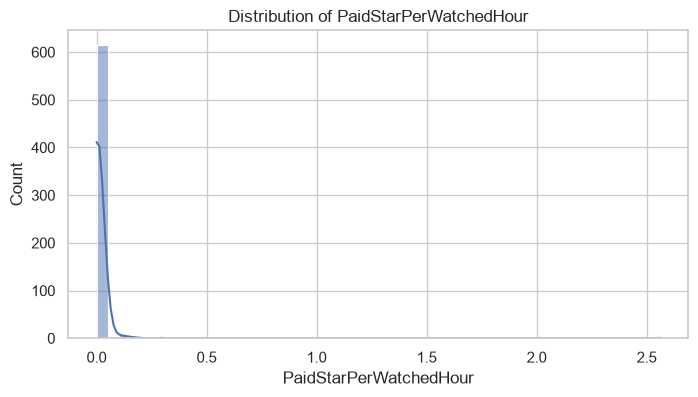

In [280]:

plt.figure(figsize=(8,4))
sns.histplot(df['PaidStarPerWatchedHour'], kde=True)
plt.title('Distribution of PaidStarPerWatchedHour')
plt.show()


## 4. Country Analysis

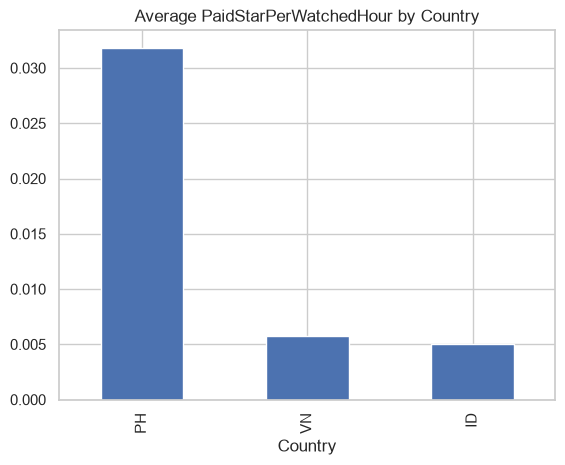

Country
PH    0.031842
VN    0.005794
ID    0.005007
Name: PaidStarPerWatchedHour, dtype: float64

In [281]:

country_avg = df.groupby('Country')['PaidStarPerWatchedHour'].mean().sort_values(ascending=False)

country_avg.plot(kind='bar')
plt.title('Average PaidStarPerWatchedHour by Country')
plt.show()

country_avg


## 5. Gender Analysis

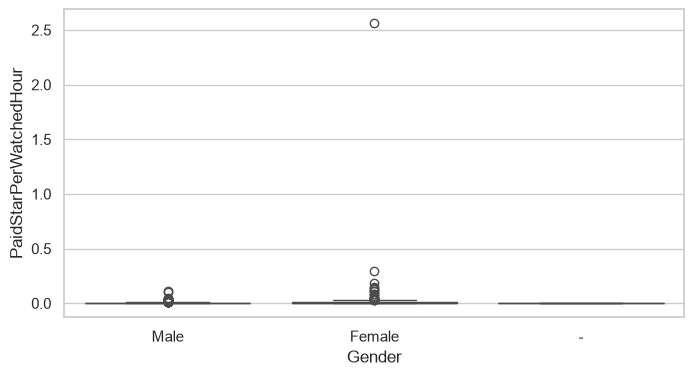

In [282]:

plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='Gender', y='PaidStarPerWatchedHour')
plt.show()


## 6. Game Analysis

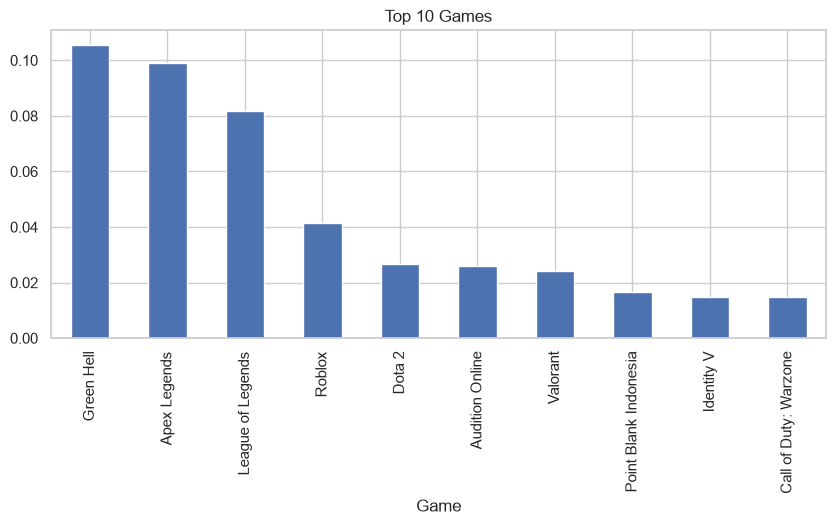

Game
Green Hell               0.105561
Apex Legends             0.098972
League of Legends        0.081605
Roblox                   0.041345
Dota 2                   0.026854
Audition Online          0.025943
Valorant                 0.024313
Point Blank Indonesia    0.016526
Identity V               0.014980
Call of Duty: Warzone    0.014799
Name: PaidStarPerWatchedHour, dtype: float64

In [283]:

game_avg = (
    df.groupby('Game')['PaidStarPerWatchedHour']
    .mean()
    .sort_values(ascending=False)
)

game_avg.head(10).plot(kind='bar', figsize=(10,4))
plt.title('Top 10 Games')
plt.show()

game_avg.head(10)


## 7. Followers vs Monetization

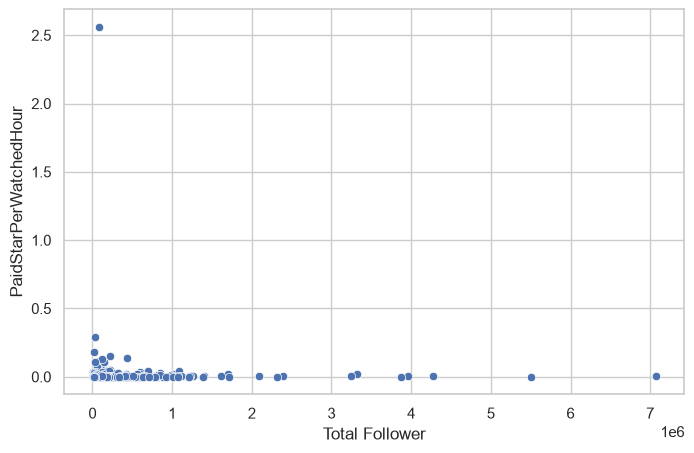

In [284]:

df['Total Follower'] = pd.to_numeric(df['Total Follower'], errors='coerce')

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='Total Follower',
    y='PaidStarPerWatchedHour'
)
plt.show()


## 8. Correlation Analysis

In [285]:

corr = df.corr(numeric_only=True)

target_corr = corr['PaidStarPerWatchedHour'].sort_values(ascending=False)

target_corr.head(20)



PaidStarPerWatchedHour                            1.000000
PaidStarPerWatchedHour.1                          1.000000
Personal_Values_Facet_Cont_Hedonism               0.140685
Character_Facet_Cont_Morality                     0.110888
Personal_Values_Facet_Cont_PowerDominance         0.103700
Temperament_Diligent                              0.100949
Self_Esteem_Cont_SEDiscrepancy                    0.096642
Personal_Values_Facet_Cont_Humility               0.085590
Self_Esteem_Cont_SEAspirationAppearance           0.083880
Personal_Values_Cont_SelfTranscendence            0.083687
Personal_Values_Facet_Cont_Reputation             0.081787
Role_Craftsman                                    0.068343
Self_Esteem_Cont_SEAspirationSociability          0.067341
Personal_Values_Facet_Cont_SelfDirectionAction    0.061797
Self_Esteem_Cont_SEDiscrepancyConfidence          0.060979
Character_Facet_Cont_SelfConsciousness            0.059360
Personal_Values_Facet_Cont_UniversalismConcern    0.0563

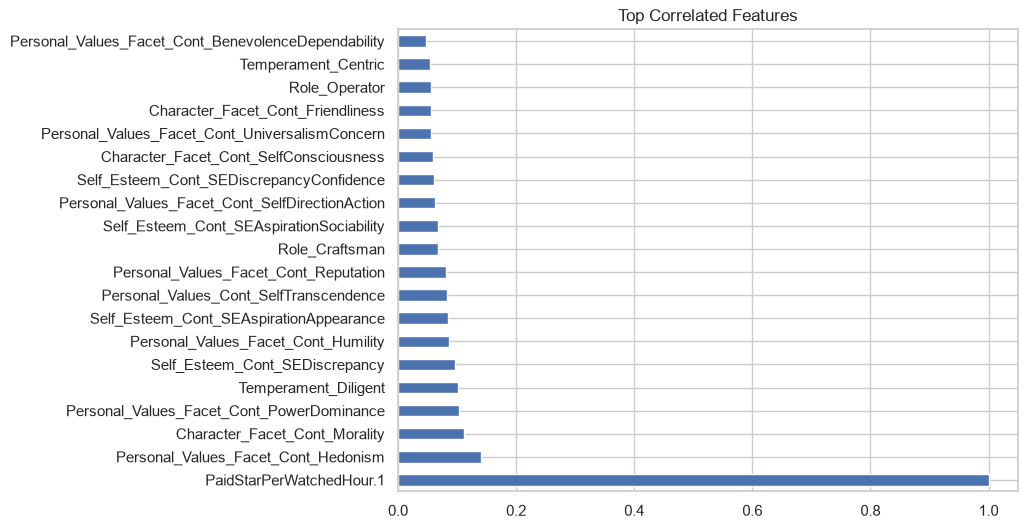

In [286]:

target_corr[1:21].plot(kind='barh', figsize=(8,6))
plt.title('Top Correlated Features')
plt.show()


In [287]:
df = df.dropna(subset=["PaidStarPerWatchedHour"])

## 9. Machine Learning - Random Forest

In [288]:

categorical_cols = [
    c for c in ['Country','Gender','Game']
    if c in df.columns
]

df_ml = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

X = df_ml.drop(columns=['PaidStarPerWatchedHour'])

X = X.select_dtypes(include=np.number)

y = df_ml['PaidStarPerWatchedHour']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print('R2:', r2_score(y_test, pred))
print('MAE:', mean_absolute_error(y_test, pred))


R2: -26.514841897687663
MAE: 0.010368965879550236


In [289]:
import numpy as np 
df_ml = df.copy()

# Hapus kolom Index yang tidak berguna
df_ml = df_ml.drop(columns=['unnamed: 0'], errors='ignore')

# Hapus baris yang targetnya kosong
df_ml = df_ml.dropna(subset=['PaidStarPerWatchedHour'])

#Transformasilog pada Target
df_ml['PaidStar_log'] = np.log1p(
    df_ml['PaidStarPerWatchedHour']
)

print(df_ml.shape)

(629, 128)


In [290]:
categorycal_col = [
    c for c in X.columns
    if "PaidStar" in c
]

df_model = pd.get_dummies(
    df_ml,
    columns=categorical_cols,
    drop_first=True
)

# X = semua fitur kecuali target asli dan target log
X = df_model.drop(
    columns=[
        'PaidStarPerWatchedHour',
        'PaidStarPerWatchedHour.1',
        'PaidStar_log',
        'Unnamed: 0'
    ],
    errors='ignore'
)

# Ambil hanya kolom numerik
X = X.select_dtypes(include=np.number)

# Isi Missing Value Jika ada
X = X.fillna(X.median())

# Target Baru
y = df_model['PaidStar_log']

print("PaidStar_log" in X.columns,
    "Unnamed: 0" in X.columns)

False False


In [291]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("R2:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))

R2: -12.901918669374625
MAE: 0.013823247105855549


## 10. Feature Importance

In [292]:

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(20)


,Feature,Importance
101,Role_Strategist,0.195009
4,Personal_Values_Facet_Cont_Hedonism,0.168102
44,Role_Guru,0.143761
0,Total Follower,0.083625
3,Character_Facet_Cont_AchievementStriving,0.061600
1,Broadcast Hours,0.035954
115,Character_Facet_Cont_Cautiousness,0.026012
16,Character_Cont_Extraversion,0.023147
25,Personal_Values_Facet_Cont_PowerDominance,0.022189
29,Personal_Values_Cont_SelfEnhancement,0.017740


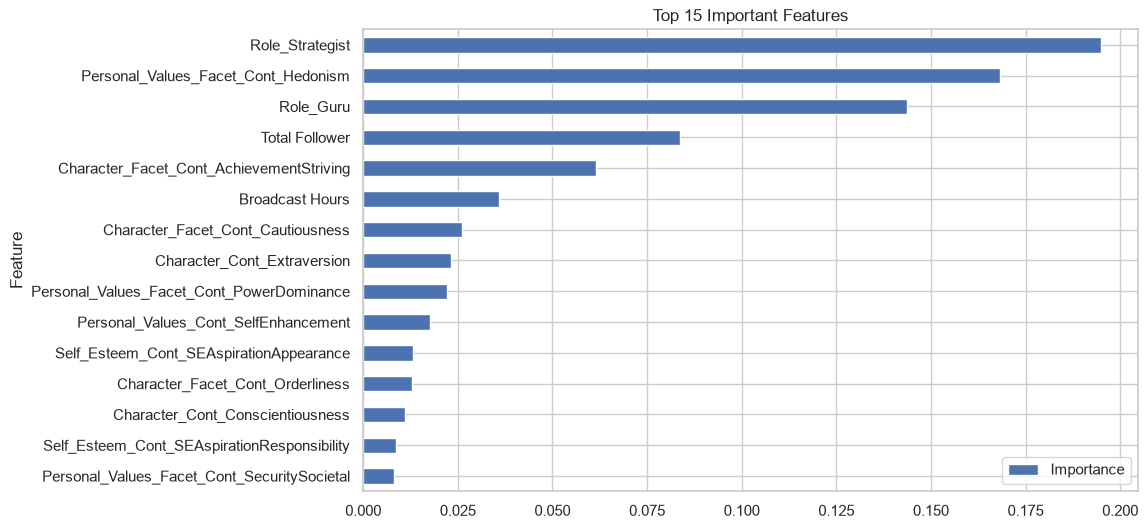

In [293]:

importance.head(15).sort_values('Importance').plot(
    x='Feature',
    y='Importance',
    kind='barh',
    figsize=(10,6)
)

plt.title('Top 15 Important Features')
plt.show()


## 11. Segmentasi Streamer High Value

In [294]:
df['Segment'] = pd.qcut(
    df['PaidStarPerWatchedHour'],
    q=4,
    labels=[
        'Low',
        'Medium',
        'High',
        'Top'
    ]
)

df.groupby('Segment')[
    'Total Follower'
].mean()



C:\Users\dreya\AppData\Local\Temp\ipykernel_9504\1789169769.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Segment'] = pd.qcut(


Segment
Low       145912.948387
Medium    244225.261146
High      262678.737179
Top       231476.566879
Name: Total Follower, dtype: float64

In [295]:

df.groupby('Segment')[
    'Broadcast Hours'
].mean()

Segment
Low       118.911392
Medium    134.592357
High      128.433121
Top       131.229299
Name: Broadcast Hours, dtype: float64

High Streamer Profile

Top Streamers:
- More followers
- More strategic traits
- Higher achievement striving
- Stronger extraversion

## 2. SHAP Analysis

Mengukur kontribusi masing-masing variabel

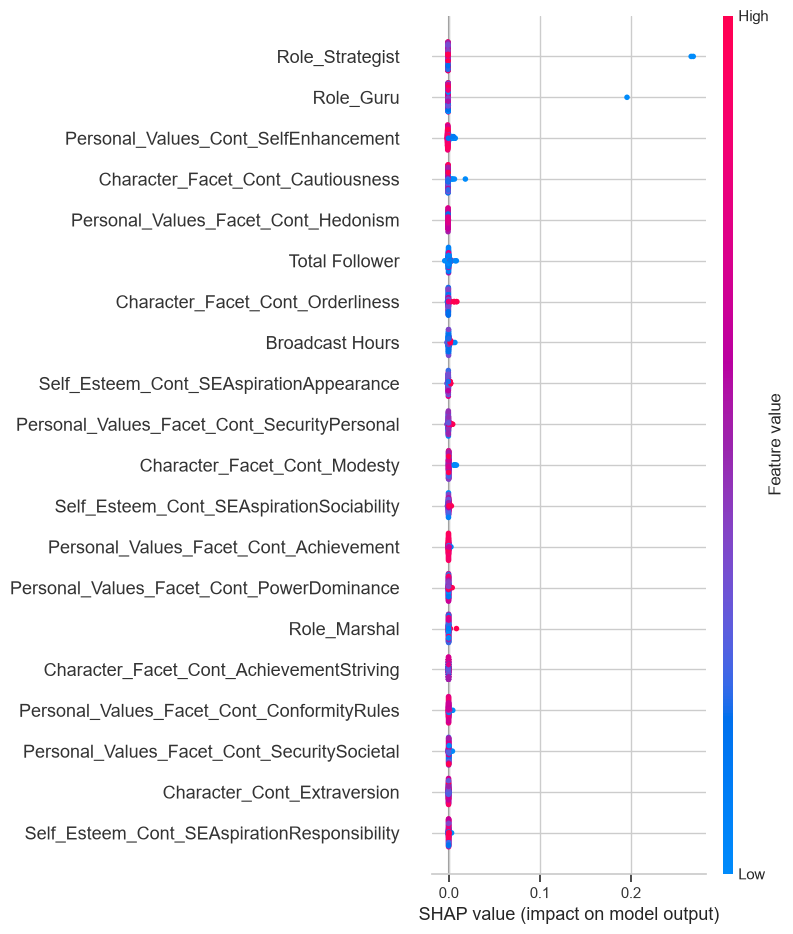

In [296]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test
)

## 13. Clustering Streamer

In [297]:
from sklearn.preprocessing import StandardScaler

cluster_data = df[cluster_features].copy()

cluster_data = cluster_data.fillna(
    cluster_data.median()
)

scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(
    cluster_data
)

In [298]:
from sklearn.cluster import KMeans

cluster_features = [
    'Total Follower',
    'Broadcast Hours',
    'Character_Cont_Extraversion',
    'Character_Cont_Conscientiousness',
    'PaidStarPerWatchedHour'
]

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(
    cluster_scaled
)

C:\Users\dreya\AppData\Local\Temp\ipykernel_9504\2723125026.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Cluster'] = kmeans.fit_predict(


In [299]:
df['Cluster'].value_counts()

df.groupby('Cluster')[
    ['Total Follower',
     'Broadcast Hours',
     'PaidStarPerWatchedHour']
].mean()

,Total Follower,Broadcast Hours,PaidStarPerWatchedHour
Cluster,,,
0,1.726399e+05,121.062842,0.010315
1,1.493405e+05,139.960317,0.004725
2,7.769100e+04,99.000000,2.561621
3,3.802582e+06,100.800000,0.004986


In [300]:
df['Cluster'].value_counts()

Cluster
0    366
1    252
3     10
2      1
Name: count, dtype: int64

In [304]:
df.groupby('Cluster')[
    [
        'Total Follower',
        'Broadcast Hours',
        'PaidStarPerWatchedHour',
        'Character_Cont_Extraversion',
        'Character_Cont_Conscientiousness'
    ]
].mean().round(2)


,Total Follower,Broadcast Hours,PaidStarPerWatchedHour,Character_Cont_Extraversion,Character_Cont_Conscientiousness
Cluster,,,,,
0,172639.94,121.06,0.01,0.40,0.43
1,149340.50,139.96,0.00,0.60,0.54
2,77691.00,99.00,2.56,0.43,0.23
3,3802582.40,100.80,0.00,0.43,0.45


## 14. Outlier Investigation

Skewness = 23.67

{'whiskers': [<matplotlib.lines.Line2D at 0x1e15cb0e990>,
 'caps': [<matplotlib.lines.Line2D at 0x1e15cb0ec10>,
 'boxes': [<matplotlib.lines.Line2D at 0x1e15cb0e850>],
 'medians': [<matplotlib.lines.Line2D at 0x1e15cb0ee90>],
 'fliers': [<matplotlib.lines.Line2D at 0x1e15cb0efd0>],
 'means': []}

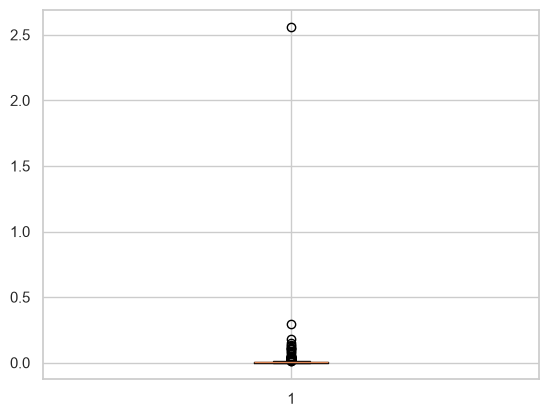

In [301]:
plt.boxplot(
    df['PaidStarPerWatchedHour']
)

In [302]:
# Top Streamer
df.nlargest(
    10,
    'PaidStarPerWatchedHour'
)

,Unnamed: 0,Country,Gender,Game,Total Follower,Broadcast Hours,PaidStarPerWatchedHour,Character_Facet_Cont_Rigidity,Character_Facet_Cont_AchievementStriving,Personal_Values_Facet_Cont_Hedonism,...,Personal_Values_Facet_Cont_Tradition,Self_Esteem_Cont_SELevelAppearance,Character_Facet_Cont_Assertiveness,Character_Facet_Cont_Cautiousness,Role_Curator,Personal_Values_Cont_Conservation,Self_Esteem_Cont_SELevelIntelligence,Temperament_Centric,Segment,Cluster
254,371,PH,Female,League of Legends,77691.0,99,2.561621,0.584904,0.147553,0.853163,...,0.345694,0.420043,0.329571,0.332496,0.087271,0.289647,0.749248,0.625,Top,2
460,774,VN,Female,League of Legends,36266.0,102,0.294624,0.561336,0.378814,0.547942,...,0.341652,0.458656,0.412747,0.387027,0.418017,0.291648,0.742862,0.250,Top,0
239,356,PH,Female,Apex Legends,24803.0,91,0.181720,0.404306,0.282998,0.632045,...,0.339147,0.470208,0.461600,0.483583,0.087755,0.303099,0.774801,0.125,Top,0
266,383,PH,Female,MLBB,214758.0,106,0.152014,0.570948,0.424839,0.571786,...,0.330251,0.662614,0.434766,0.313958,0.197018,0.298902,0.706129,0.500,Top,0
326,443,PH,Female,MLBB,435802.0,106,0.136702,0.420339,0.434771,0.727431,...,0.314646,0.458395,0.455181,0.481494,0.195193,0.304335,0.761978,0.500,Top,0
387,504,PH,Female,Dota 2,124110.0,189,0.129032,0.560150,0.423031,0.559924,...,0.330251,0.614006,0.435918,0.318109,0.211657,0.306294,0.706129,0.500,Top,0
262,379,PH,Female,Apex Legends,82984.0,65,0.114806,0.527264,0.498599,0.638949,...,0.319338,0.490975,0.549720,0.249064,0.268655,0.287754,0.662915,0.625,Top,0
319,436,PH,Female,MLBB,139153.0,127,0.111758,0.652047,0.365411,0.548008,...,0.315287,0.477315,0.681818,0.290618,0.124450,0.279540,0.720876,0.625,Top,0
274,391,PH,Male,Valorant,149000.0,227,0.107935,0.524963,0.584384,0.317281,...,0.345696,0.687994,0.336021,0.396449,0.157436,0.310952,0.842294,0.625,Top,0
405,719,VN,Male,Green Hell,30300.0,120,0.105561,0.633160,0.641683,0.334955,...,0.379392,0.780850,0.468794,0.482814,0.332000,0.301912,0.793817,0.125,Top,0


## 15. Revenue Prediction Improvement

R² = -12.9

In [303]:
from xgboost import XGBRegressor


## 11. Business Insights

Setelah menjalankan notebook:

1. Identifikasi 3-5 fitur teratas yang memengaruhi PaidStarPerWatchedHour.
2. Bandingkan performa negara.
3. Bandingkan performa gender.
4. Identifikasi game dengan monetisasi tertinggi.
5. Buat rekomendasi untuk tim Operasional dan Executive.

## 12. Next 7 Days Improvement

- Segmentasi streamer high-value.
- SHAP analysis.
- Clustering streamer.
- Outlier investigation.
- Revenue prediction improvement.
